## Student Name: Gabriel Espinoza Rojas

## Student ID: 22176691

## Imports

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
%matplotlib inline
# for more beautiful plots
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

# Task 1: Exploratory Data Analysis (EDA)

Perform EDA of the bank dataset by following the notebook <code>Tutorial 1-1 - Exploratory Data Analysis.ipynb</code> as an example.

1. Formulate a particular question that might be interesting to answer by exploring the bank dataset (approx. 50 words in a markdown cell).
2. Calculate statistics for the numerical and categorical attributes. Draw a short conclusion (approx. 150 words in a markdown cell).
3. Use at least two different plotting techniques to plot the distribution of some numerical attributes. Draw short conclusions (approx. 150 words in a markdown cell).
4. Generate at least two plots with the combined distribution of attributes. Draw a short conclusion (approx. 150 words in a markdown cell).
5. Make sure your conclusions are related to the question you have formulated.

In [2]:
# let's load up the data set and have a quick look 

bank_dataset = pd.read_csv("./bank.csv")

print(bank_dataset.dtypes)
print(bank_dataset.shape)
bank_dataset.head()

age           float64
job            object
marital        object
education      object
default        object
balance         int64
housing        object
loan           object
contact        object
day             int64
month          object
duration        int64
campaign        int64
pdays           int64
previous        int64
poutcome       object
subscribed     object
dtype: object
(2000, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,subscribed
0,32.0,technician,single,tertiary,no,392,yes,no,cellular,1,apr,957,2,131,2,failure,no
1,39.0,technician,divorced,secondary,no,688,yes,yes,cellular,1,apr,233,2,133,1,failure,no
2,59.0,retired,married,secondary,no,1035,yes,yes,cellular,1,apr,126,2,239,1,failure,no
3,47.0,blue-collar,married,secondary,no,398,yes,yes,cellular,1,apr,274,1,238,2,failure,no
4,54.0,retired,married,secondary,no,1004,yes,no,cellular,1,apr,479,1,307,1,failure,no


In [3]:
bank_dataset.tail()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,subscribed
1995,20.0,student,single,NaN,no,2785,no,no,cellular,16,sep,327,2,-1,0,NaN,yes
1996,28.0,admin.,single,secondary,no,127,no,no,cellular,16,sep,1334,2,-1,0,NaN,yes
1997,81.0,retired,married,primary,no,1154,no,no,telephone,17,sep,231,1,-1,0,NaN,yes
1998,46.0,services,married,primary,no,4343,yes,no,NaN,20,sep,185,1,-1,0,NaN,yes
1999,40.0,entrepreneur,married,secondary,no,6403,no,no,cellular,22,sep,208,2,-1,0,NaN,yes


### 1. <strong>Formulate a particular question that might be interesting to answer by exploring the bank dataset </strong> (approx. 50 words in a markdown cell).



The dataset contains client-related and campaign information about bank calls promoting a subscription service. It would be interesting to see what's the impact of loans (mortgage or personal) over the subscription rate.

<!--"what affects subscription more? Education or occupation?"-->

<!--other good ones-->
<!--What influences the subscription success?-->

<!--Can I guess the balance of a customer just by the interaction with the bank?-->

<!--Can I guess the duration for the call for successful interactions.-->

<!--The bank wants to know what attributes matter the most to get more subscribers and improve their marketing campaign?-->

### <strong>2. Calculate statistics for the numerical and categorical attributes. Draw a short conclusion </strong> (approx. 150 words in a markdown cell).

In [4]:
# Print statistical summary for all numerical attributes
bank_dataset.describe()

,age,balance,day,duration,campaign,pdays,previous
count,1988.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,41.753018,1413.663500,13.851500,292.020500,1.909500,167.896000,2.561500
std,12.724358,3131.224213,9.712189,221.557295,1.378862,131.754126,3.400735
min,18.000000,-980.000000,1.000000,7.000000,1.000000,-1.000000,0.000000
25%,32.000000,201.500000,5.000000,146.000000,1.000000,75.750000,1.000000
50%,38.000000,551.000000,12.000000,236.000000,1.000000,182.000000,2.000000
75%,50.000000,1644.500000,23.000000,379.000000,2.000000,251.000000,3.000000
max,93.000000,81204.000000,31.000000,1823.000000,11.000000,854.000000,55.000000


In [5]:
categorical_cols = [
    'job',
    'marital',
    'education',
    'default',
    'housing',
    'loan',
    'contact',
    'month',
    'poutcome',
    'subscribed'
]
for col in categorical_cols:
    print(f"total count: {bank_dataset[col].count()}, frequency table: {bank_dataset[col].value_counts()} \n")

total count: 1990, frequency table: job
management       461
technician       348
blue-collar      298
admin.           247
services         165
retired          162
student           96
unemployed        69
self-employed     64
entrepreneur      45
housemaid         35
Name: count, dtype: int64 

total count: 2000, frequency table: marital
married     1111
single       674
divorced     215
Name: count, dtype: int64 

total count: 1896, frequency table: education
secondary    995
tertiary     684
primary      217
Name: count, dtype: int64 

total count: 2000, frequency table: default
no     1985
yes      15
Name: count, dtype: int64 

total count: 2000, frequency table: housing
no     1037
yes     963
Name: count, dtype: int64 

total count: 2000, frequency table: loan
no     1750
yes     250
Name: count, dtype: int64 

total count: 1809, frequency table: contact
cellular     1663
telephone     146
Name: count, dtype: int64 

total count: 2000, frequency table: month
feb    404
may    

### conclusions

The datasets has 17 columns. client-related are: 
age (numerical, values are missing), 
job (categorical, values are missing), 
marital (categorical), 
education (categorical, values are missing and there's an ordinal behaviour), 
default (categorical, binary behaviour), 
balance (numerical, presents strong outliers), 
<strong>housing</strong> (categorical, binary behaviour), 
<strong>loan</strong> (categorical, binary behaviour) 
and contact (categorical, values are missing). 


The campaign-related attributes are: 
day (numerical, cyclical behaviour), 
month (categorical, cyclical behaviour), 
duration (numerical, presents strong outliers), 
campaign (numerical), pdays (numerical), 
previous (numerical) 
and poutcome (categorical, values are missing). 

Together they add to 16, the last variable is the target: <strong>subscribed</strong> (categorical, binary behaviour).

From the [dataset description](https://archive.ics.uci.edu/dataset/222/bank+marketing) we know that the columns related to loans are <strong>housing</strong> (<i>has housing loan?</i>) and <strong>loan</strong> (<i>has personal loan?</i>), 
their binary/categorial behaviour is a consequence of the answer they are provided. No missing values. 'housing is almost perfectly balance, loan instead has only $12.5%$ 'yes' values.

### 3. <strong>Use at least two different plotting techniques to plot the distribution of some numerical attributes. Draw short conclusions</strong> (approx. 150 words in a markdown cell).

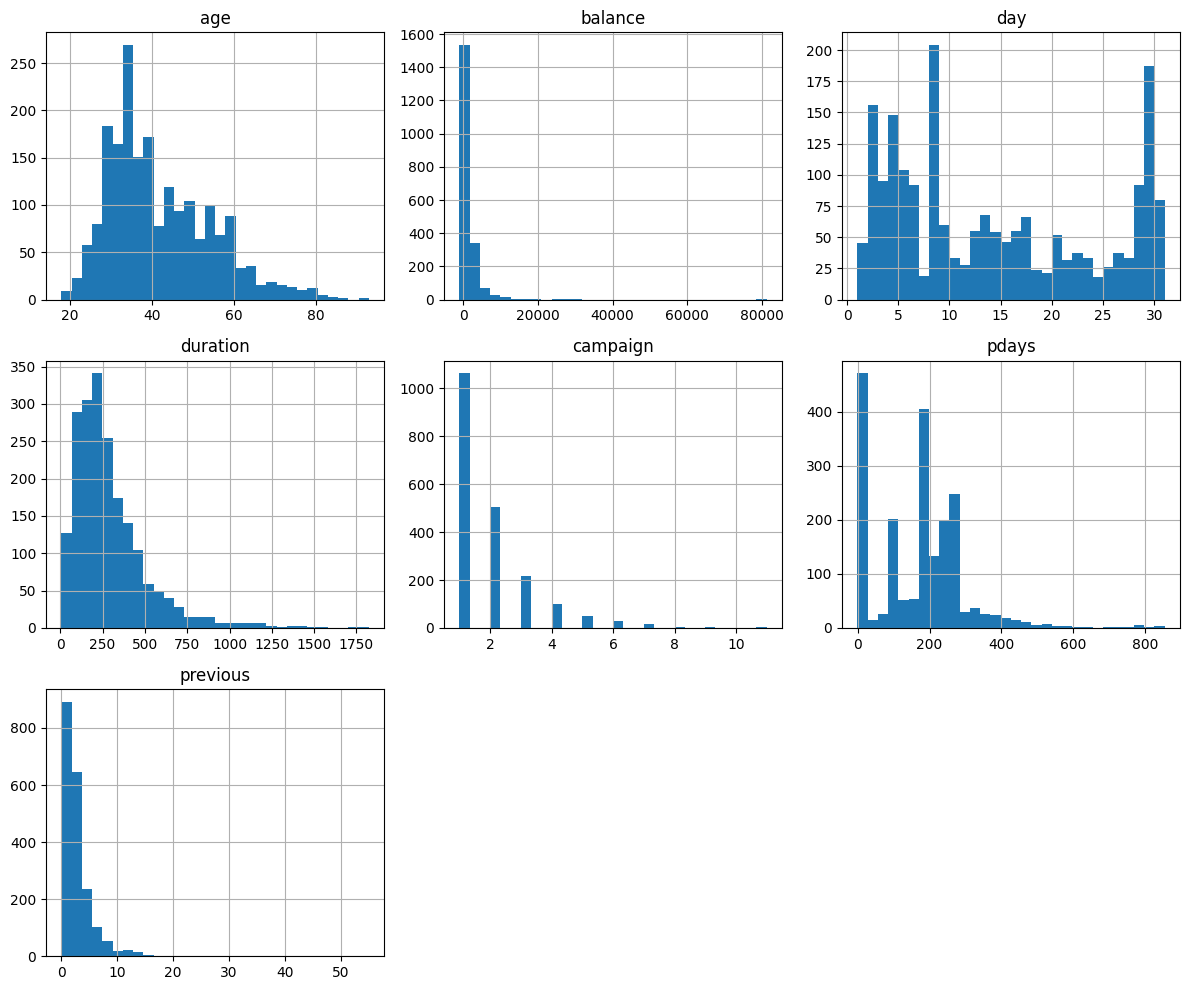

In [6]:
# histograms

relevant_columns = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
#relevant_columns = ['age', 'balance', 'duration', 'campaign', 'previous']

bank_dataset[relevant_columns].hist(figsize=(12,10), bins=30)
plt.tight_layout()
plt.show()

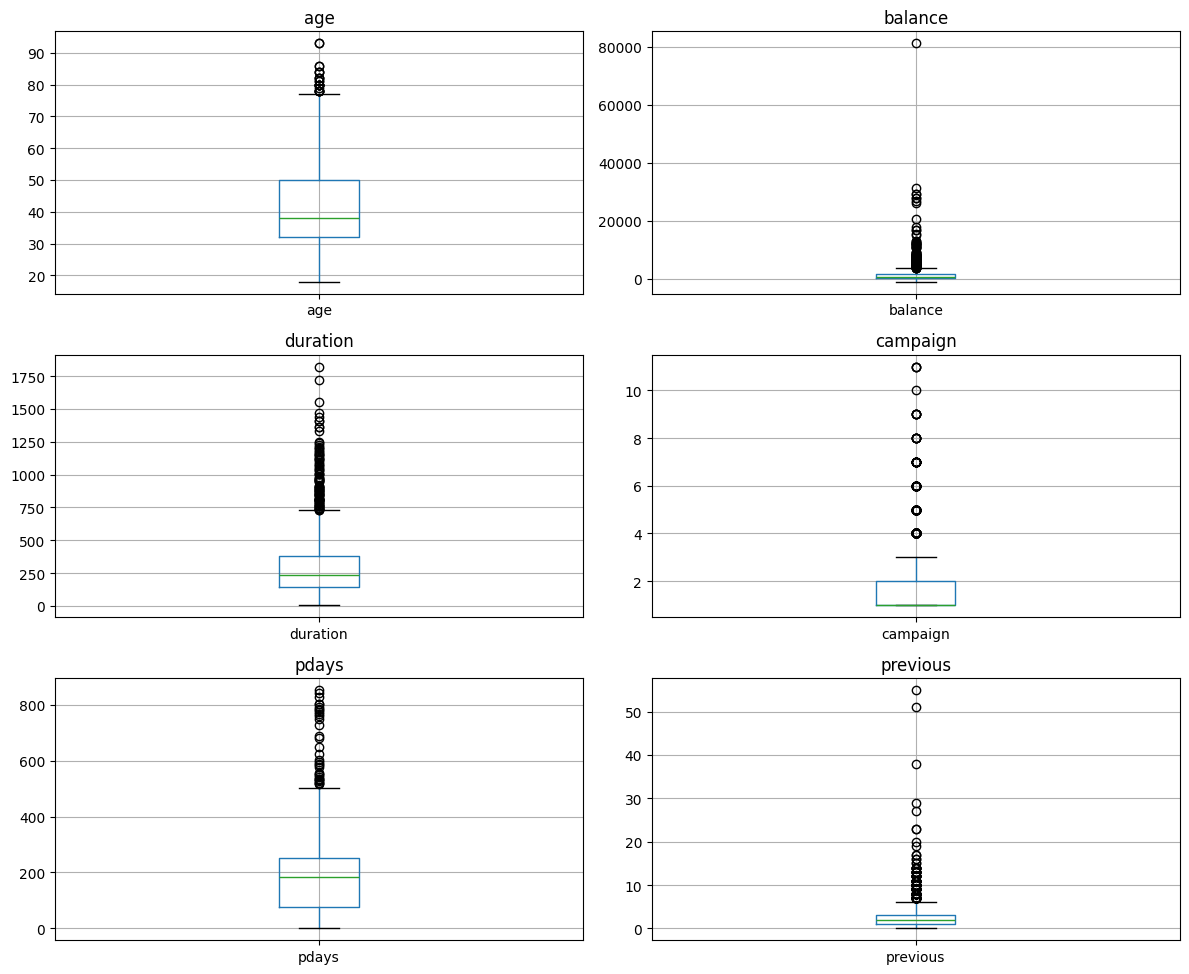

In [7]:
numeric_cols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']

plt.figure(figsize=(12, 10))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 2, i)
    bank_dataset.boxplot(column=col)
    plt.title(col)
    plt.suptitle("")  # removes automatic title

plt.tight_layout()
plt.show()

### conclusions

As suspected from the previous section, both 'balance' and 'duration' columns have outliers, and are also skewed. 

The cyclical behaviour in column 'day' works on a monthly basis. 

The 'campaign' column distribution is discrete. 

The nature of the 'pdays' column creates a strange distribution. These are all circumstances that should be addressed in the next task (data preparation).

It's also worth mentioning that distributions for 'campaign' and 'previous' columns are right-skewed, which is expected since they have many small values and a few large values.

### 4. <strong>Generate at least two plots with the combined distribution of attributes. Draw a short conclusion </strong>(approx. 150 words in a markdown cell).

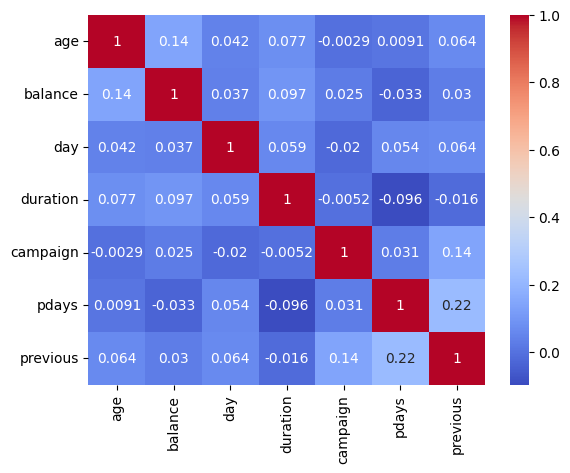

In [8]:
#correlation matrix
sns.heatmap(bank_dataset.corr(numeric_only=True), annot=True, cmap='coolwarm');

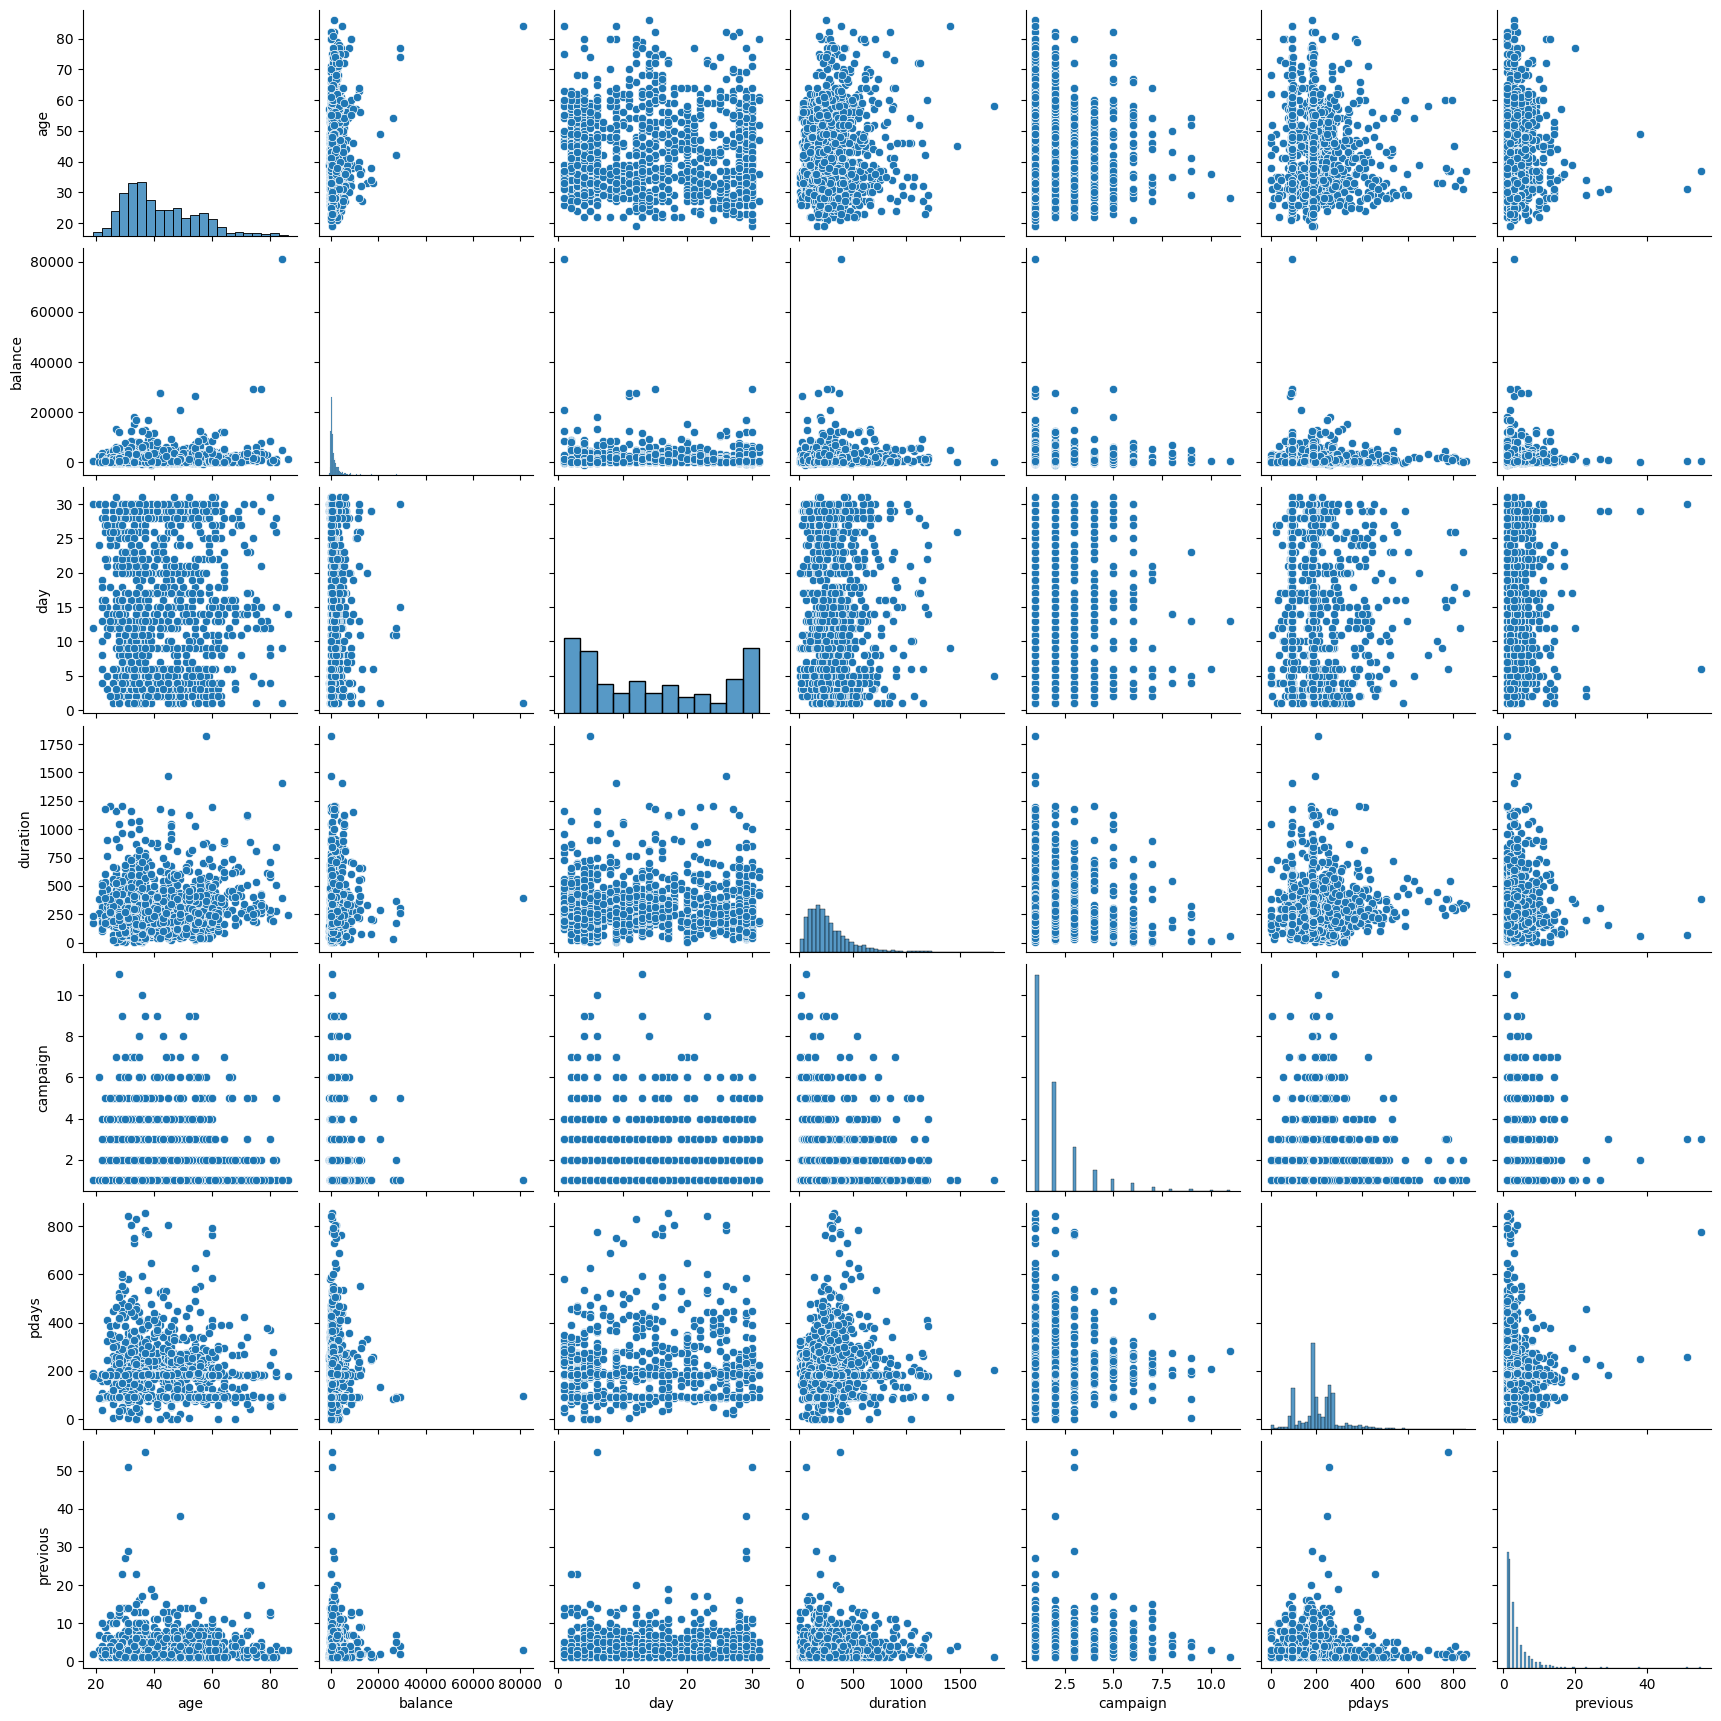

In [9]:
# note that by applying the method dropna() we drop all rows with missing values 
# looking for correlation
sns.pairplot(data=bank_dataset.dropna())
plt.show()

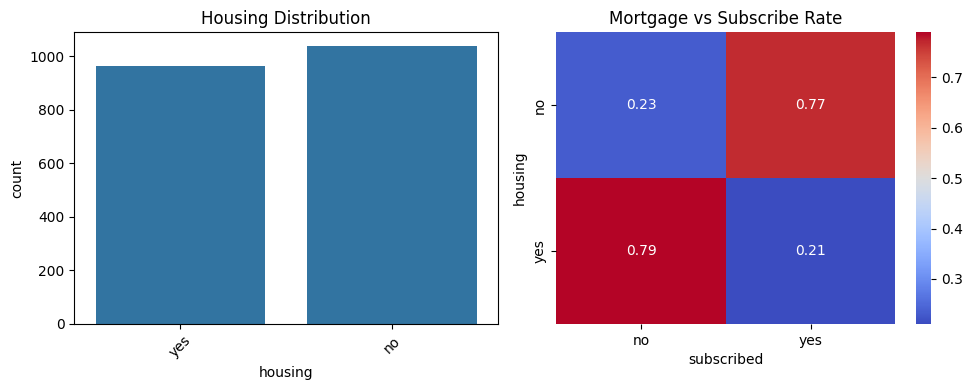

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# housing countplot
sns.countplot(x=bank_dataset['housing'], ax=axes[0])
axes[0].set_title("Housing Distribution")
axes[0].tick_params(axis='x', rotation=45)

# housing x subscribed heatmap
crosstab_CL = pd.crosstab(
    bank_dataset['housing'],
    bank_dataset['subscribed'],
    normalize='index'
)

sns.heatmap(
    crosstab_CL,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    ax=axes[1]
)

axes[1].set_title("Mortgage vs Subscribe Rate")

plt.tight_layout()
plt.show()

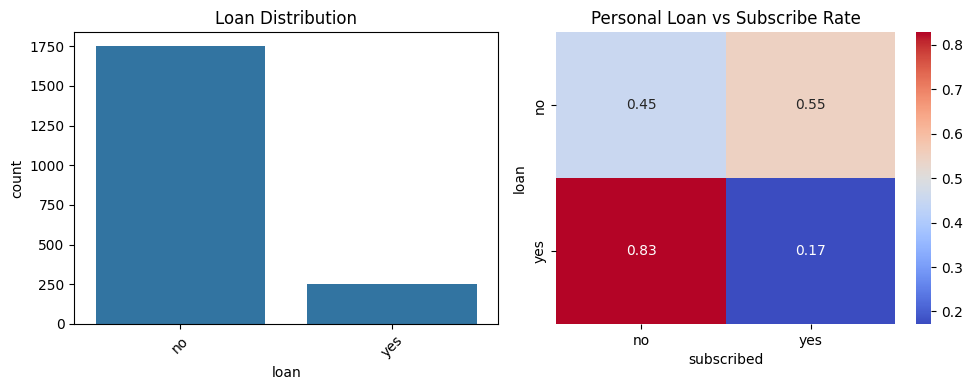

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# loan countplot
sns.countplot(x=bank_dataset['loan'], ax=axes[0])
axes[0].set_title("Loan Distribution")
axes[0].tick_params(axis='x', rotation=45)

# loan x subscribed heatmap
crosstab_CL = pd.crosstab(
    bank_dataset['loan'],
    bank_dataset['subscribed'],
    normalize='index'

)
sns.heatmap(
    crosstab_CL,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    ax=axes[1]
)

axes[1].set_title("Personal Loan vs Subscribe Rate")

# Layout adjustment
plt.tight_layout()
plt.show()

Group counts
loan  housing
no    no         957
      yes        793
yes   no          80
      yes        170
dtype: int64


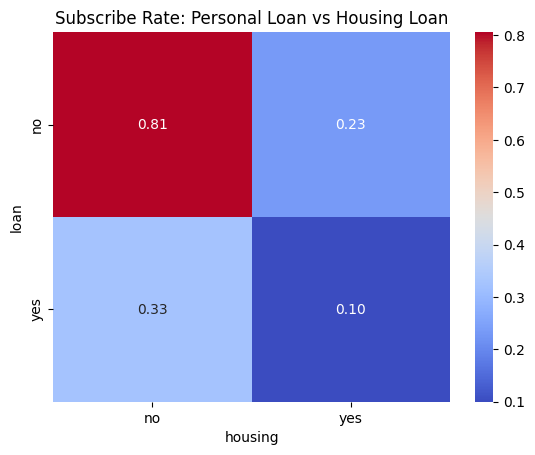

In [12]:
print("Group counts")
print(bank_dataset.groupby(['loan', 'housing']).size())

pivot = bank_dataset.pivot_table(
    values='subscribed',
    index='loan',
    columns='housing',
    aggfunc=lambda x: x.map({'yes':1, 'no':0}).mean())

sns.heatmap(pivot, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Subscribe Rate: Personal Loan vs Housing Loan")
plt.show()

### Conclusions

The correlation matrix shows no strong relationship between numerical features. The pair plots confirm this (important to mention that missing values were not considered). 

The columns of interest were then plotted agaisnt the target column, first individually and then together. From the mortgage analysis it can be said that for this dataset, individuals with a housing loan are less likely to subscribe, as only $21%$ of the people with this feature are subscribed. For personal loans it's important to mention that the distribution is unbalanced, with the sample showing a bast majority of people with no personal loans ($87.5%$); but the story is very similar than with the mortgages, only $17%$ of individuals with personal loans are subscribed.

To tie these observations together I used a pivot table to show the relationship between the two types of loans and subscribe rates. This last heatmap shows that individuals with both loans only have a $10%$ rate of subscription. The opposite case shows a $81%$ rate. 

# Task 2: Data Preparation

Continue with preparing the bank dataset for machine learning by following the notebook <code>Tutorial 1-2 - Data Preparation.ipynb</code> as an example.

Ensure that you have:

1. encoded all categorical attributes as numerical,
2. filled in all missing values,
3. applied a scaler to rescale features,
4. treated outliers and skewed attribute distribution appropriately,
5. created at least one new feature from the existing ones.

Shortly describe and justify the data preparation choices you have made in markdown cells.

In [13]:
# Before we start transforming the dataset let's make a copy of it.
bank_dataset_original = bank_dataset.copy()

### 1. <strong>encoded all categorical attributes as numerical</strong>

In [14]:
# month column is categorical but also cyclical

# map month column to numerical values for cyclical transformation
month_map = {
    'jan':1,'feb':2,'mar':3,'apr':4,'may':5,'jun':6,
    'jul':7,'aug':8,'sep':9,'oct':10,'nov':11,'dec':12
}

bank_dataset['month_num'] = bank_dataset['month'].map(month_map)

#cyclical encoding should reflect the true cycle, not the observed data range
max_month = 12 # max(bank_dataset['month_num'])

# apply cyclical encoding
bank_dataset['month_sin'] = np.sin(2 * np.pi * bank_dataset['month_num'] / max_month)
bank_dataset['month_cos'] = np.cos(2 * np.pi * bank_dataset['month_num'] / max_month)

# Drop original columns
bank_dataset.drop(columns=['month', 'month_num'], inplace=True)

#let's encode the numerical day column in the same manner while we are at it

#cyclical encoding should reflect the true cycle, not the observed data range
max_day = 31 # max(bank_dataset['day'])

# apply cyclical encoding
bank_dataset['day_sin'] = np.sin(2 * np.pi * bank_dataset['day'] / max_day)
bank_dataset['day_cos'] = np.cos(2 * np.pi * bank_dataset['day'] / max_day)

# Drop original columns
bank_dataset.drop(columns=['day'], inplace=True)

# After encoding, always ensure the column has the correct numeric type.
bank_dataset.tail()

#Note: the feature_engine library has a class that can perform this operation as well
#however, adding an extra library in the imports to perform this is undesirable (personal opinion)

,age,job,marital,education,default,balance,housing,loan,contact,duration,campaign,pdays,previous,poutcome,subscribed,month_sin,month_cos,day_sin,day_cos
1995,20.0,student,single,NaN,no,2785,no,no,cellular,327,2,-1,0,NaN,yes,-1.0,-1.836970e-16,-0.101168,-0.994869
1996,28.0,admin.,single,secondary,no,127,no,no,cellular,1334,2,-1,0,NaN,yes,-1.0,-1.836970e-16,-0.101168,-0.994869
1997,81.0,retired,married,primary,no,1154,no,no,telephone,231,1,-1,0,NaN,yes,-1.0,-1.836970e-16,-0.299363,-0.954139
1998,46.0,services,married,primary,no,4343,yes,no,NaN,185,1,-1,0,NaN,yes,-1.0,-1.836970e-16,-0.790776,-0.612106
1999,40.0,entrepreneur,married,secondary,no,6403,no,no,cellular,208,2,-1,0,NaN,yes,-1.0,-1.836970e-16,-0.968077,-0.250653


For the columns 'day' and 'month', I used these transformations:
  
$\text{month}_{\sin} = \sin\left(\frac{2\pi \cdot \text{month}}{12}\right)$,

$\text{month}_{\sin} = \sin\left(\frac{2\pi \cdot \text{month}}{12}\right)$, 

$\text{month}_{\cos} = \cos\left(\frac{2\pi \cdot \text{month}}{12}\right)$

and $\text{day}_{\sin} = \sin\left(\frac{2\pi \cdot \text{day}}{31}\right)$

to model the cyclical behaviour. I'm aware that the feature_engine library has a class that can perform this operation as well. However, adding an extra library in the imports to perform this is something I'd avoid.

For conversations with peers, I understood one-hot encoding column 'job' with NaN values could add noise (and extra column that adds little insight). For ten values and understanding the relation with other columns I decide to impute these values.

In [15]:
# missing values
 
bank_dataset[bank_dataset['job'].isna()]


,age,job,marital,education,default,balance,housing,loan,contact,duration,campaign,pdays,previous,poutcome,subscribed,month_sin,month_cos,day_sin,day_cos
255,42.0,NaN,single,primary,no,2398,yes,no,cellular,144,2,271,2,failure,no,0.866025,5.000000e-01,0.571268,0.820763
257,46.0,NaN,married,NaN,no,677,no,no,cellular,425,1,82,1,failure,no,0.866025,5.000000e-01,0.571268,0.820763
831,41.0,NaN,single,primary,no,2398,yes,no,NaN,287,2,-1,0,NaN,no,0.500000,-8.660254e-01,0.998717,-0.050649
1223,55.0,NaN,married,secondary,no,2206,no,no,cellular,265,1,91,5,success,yes,-0.866025,-5.000000e-01,0.651372,-0.758758
1281,50.0,NaN,married,NaN,no,558,no,no,cellular,464,1,683,6,failure,yes,-0.500000,-8.660254e-01,0.968077,-0.250653
1669,54.0,NaN,married,secondary,no,2206,no,no,cellular,260,1,91,4,success,yes,0.500000,-8.660254e-01,0.485302,-0.874347
1711,77.0,NaN,married,NaN,no,397,no,no,telephone,300,3,-1,0,NaN,yes,0.500000,-8.660254e-01,0.988468,0.151428
1801,28.0,NaN,single,NaN,no,326,no,no,cellular,450,1,231,1,success,yes,-0.866025,5.000000e-01,0.790776,-0.612106
1868,48.0,NaN,single,NaN,no,1819,no,no,cellular,1440,1,458,1,failure,yes,-1.000000,-1.836970e-16,0.394356,0.918958
1975,45.0,NaN,married,tertiary,no,406,no,no,cellular,314,1,-1,0,NaN,yes,-1.000000,-1.836970e-16,0.988468,0.151428


When 'job' is 'retired', the value of age is likely high. The mode is the value that appears more times in the column. 

In [16]:
"""
- job (Categorical): ("admin", "unemployed","management","housemaid","entrepreneur","student","blue-collar","self-employed","retired","technician","services") 
missing 2000-1990=10 values
"""

# Lori raised the fact that this specific individual is likely retired
bank_dataset.loc[
    (bank_dataset['age'] == 77) & (bank_dataset['job'].isna()),
    'job'
] = 'retired'

# the rest we can impute with the mode job of this dataset
bank_dataset['job'] = bank_dataset['job'].fillna(bank_dataset['job'].mode()[0])

I used imputation over the column 'job' (categorical) to deal with 10 missing values, with one imputation being an educated guess and the rest using the mode of the column. The decision to use this techniques came from the realisation that the amounts of rows missing for this column was relatively small (around $0.5%$ for the provided dataset).

Another realisation for the forums was that the missing values in the column 'poutcome' could be a business signal. Instead of leaving pandas' function take the Nan values to form a column, we can give it a meaning. 

In [17]:
"""
- poutcome (Categorical): ("other","failure","success") 
missing 2000-1546= 454 values
"""
# MNAR: Missing Not at Random
bank_dataset['poutcome'] = bank_dataset['poutcome'].fillna('first_contact')

In [18]:
#the categorical features with missing values:
#https://queirozf.com/entries/one-hot-encoding-a-feature-on-a-pandas-dataframe-an-example

"""
- education (Categorical): education Level ("secondary","primary","tertiary") 
missing 2000-1896= 114 values

- contact (Categorical): ("telephone","cellular")
missing 2000-1809= 191 values

- poutcome (Categorical): ("other","failure","success") 
missing 2000-1546= 454 values
"""

# first one-hot encode the categorical columns with NaNs

bank_dataset = pd.get_dummies(bank_dataset, columns=['education', 'contact'], 
                        dummy_na=True, drop_first=True) 

# After encoding, always ensure the column has the correct numeric type.
bank_dataset.tail()

# Note: Prof. mentioned in class alternative method (using OneHotEncoder class from scikit-learn) but I'm following the provided example

,age,job,marital,default,balance,housing,loan,duration,campaign,pdays,...,subscribed,month_sin,month_cos,day_sin,day_cos,education_secondary,education_tertiary,education_nan,contact_telephone,contact_nan
1995,20.0,student,single,no,2785,no,no,327,2,-1,...,yes,-1.0,-1.836970e-16,-0.101168,-0.994869,False,False,True,False,False
1996,28.0,admin.,single,no,127,no,no,1334,2,-1,...,yes,-1.0,-1.836970e-16,-0.101168,-0.994869,True,False,False,False,False
1997,81.0,retired,married,no,1154,no,no,231,1,-1,...,yes,-1.0,-1.836970e-16,-0.299363,-0.954139,False,False,False,True,False
1998,46.0,services,married,no,4343,yes,no,185,1,-1,...,yes,-1.0,-1.836970e-16,-0.790776,-0.612106,False,False,False,False,True
1999,40.0,entrepreneur,married,no,6403,no,no,208,2,-1,...,yes,-1.0,-1.836970e-16,-0.968077,-0.250653,True,False,False,False,False


For 'education', 'contact' and columns, I used one-hot encoded <code>pd.get_dummies(bank_dataset, columns=[...], dummy_na=True)</code> since some values were missing. Note: Prof. mentioned in class 'that's one of the way to do one-hot encoding, but there is actually a <code>OneHotEncoder</code> class in scikit-learn that's better' (something to consider). I must mention that initially, I had decided that ordinal encoding the column 'education'. But after conversations with peers, due to the missing values, the argument to use an ordinal encoding weakens. It could still work but the missing values would need to be imputated, my mistake was using one-hot encoding to treat them.

In [19]:
#Categorical binary columns

"""
- default (Categorical/Binary): has credit in default? ("yes","no")

- housing (Categorical/Binary): has housing loan? ("yes","no")

- loan (Categorical/Binary): has personal loan? ("yes","no")

- subscribed (Categorical/Binary): has the client subscribed a term deposit? ("yes","no")
"""

binary_map = {'no': 0, 'yes': 1}

for col in ['default', 'housing', 'loan', 'subscribed']:
    bank_dataset[col] = bank_dataset[col].map(binary_map)

# After encoding, always ensure the column has the correct numeric type.
bank_dataset.tail()

,age,job,marital,default,balance,housing,loan,duration,campaign,pdays,...,subscribed,month_sin,month_cos,day_sin,day_cos,education_secondary,education_tertiary,education_nan,contact_telephone,contact_nan
1995,20.0,student,single,0,2785,0,0,327,2,-1,...,1,-1.0,-1.836970e-16,-0.101168,-0.994869,False,False,True,False,False
1996,28.0,admin.,single,0,127,0,0,1334,2,-1,...,1,-1.0,-1.836970e-16,-0.101168,-0.994869,True,False,False,False,False
1997,81.0,retired,married,0,1154,0,0,231,1,-1,...,1,-1.0,-1.836970e-16,-0.299363,-0.954139,False,False,False,True,False
1998,46.0,services,married,0,4343,1,0,185,1,-1,...,1,-1.0,-1.836970e-16,-0.790776,-0.612106,False,False,False,False,True
1999,40.0,entrepreneur,married,0,6403,0,0,208,2,-1,...,1,-1.0,-1.836970e-16,-0.968077,-0.250653,True,False,False,False,False


For columns 'default', 'housing', 'loan' and 'subscribed', I used binary mapping due to their values all being 'yes' or 'no'. A perk of doing this instead of one-hot encoding them is that we avoid unnecessary column expansions.

In [20]:
# Before calling get_dummies, let's inspect what pandas thinks is categorical
bank_dataset.select_dtypes(include=['object', 'string', 'category', 'bool']).columns.tolist()

['job',
 'marital',
 'poutcome',
 'education_secondary',
 'education_tertiary',
 'education_nan',
 'contact_telephone',
 'contact_nan']

And I decided to leave the columns with imputed values or no missing values in a separated cell.

In [21]:
# one-hot encode categorical columns left (no missing values)

bank_dataset = pd.get_dummies(bank_dataset, columns=['marital' , 'job', 'poutcome'], drop_first=True) 

bank_dataset.tail()

,age,default,balance,housing,loan,duration,campaign,pdays,previous,subscribed,...,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,poutcome_first_contact,poutcome_other,poutcome_success
1995,20.0,0,2785,0,0,327,2,-1,0,1,...,False,False,False,False,True,False,False,True,False,False
1996,28.0,0,127,0,0,1334,2,-1,0,1,...,False,False,False,False,False,False,False,True,False,False
1997,81.0,0,1154,0,0,231,1,-1,0,1,...,False,True,False,False,False,False,False,True,False,False
1998,46.0,0,4343,1,0,185,1,-1,0,1,...,False,False,False,True,False,False,False,True,False,False
1999,40.0,0,6403,0,0,208,2,-1,0,1,...,False,False,False,False,False,False,False,True,False,False


For encoding categorical columns without missing values ('marital') I used get_dummies again without <code>dummy_na=True</code>. 

### 2. filled in all missing values

In [22]:
bank_dataset.isna().sum()

age                       12
default                    0
balance                    0
housing                    0
loan                       0
duration                   0
campaign                   0
pdays                      0
previous                   0
subscribed                 0
month_sin                  0
month_cos                  0
day_sin                    0
day_cos                    0
education_secondary        0
education_tertiary         0
education_nan              0
contact_telephone          0
contact_nan                0
marital_married            0
marital_single             0
job_blue-collar            0
job_entrepreneur           0
job_housemaid              0
job_management             0
job_retired                0
job_self-employed          0
job_services               0
job_student                0
job_technician             0
job_unemployed             0
poutcome_first_contact     0
poutcome_other             0
poutcome_success           0
dtype: int64

In [23]:
"""
- age (Integer): missing 2000-1988=12 values
"""

#let's use the mean of each job to fill missing values

#easiest way to fill in the missing values is:
bank_dataset['age'] = bank_dataset['age'].fillna(bank_dataset['age'].mean())

I used imputation over the numerical column 'age' I used the mean to imputate 12 missing values. The decision to use this techniques came from the realisation that the amounts of rows missing for this column was relatively small (around $0.5%$ for the provided dataset).

### 3. <strong> apply a scaler to rescale features</strong>

In [24]:
bank_dataset['campaign'].value_counts()

campaign
1     1063
2      506
3      219
4       99
5       50
6       31
7       17
8        6
9        5
11       3
10       1
Name: count, dtype: int64

'campaign' is rather an ordinal than a continuous numerical feature and none of its values appear to be actual outliers. To bring it to the interval $[0,1]$ we can apply MinMaxScaler to it. 


In [25]:
min_max_scaler = MinMaxScaler()
bank_dataset['campaign'] = min_max_scaler.fit_transform(bank_dataset[['campaign']])

bank_dataset['campaign'].value_counts()

campaign
0.0    1063
0.1     506
0.2     219
0.3      99
0.4      50
0.5      31
0.6      17
0.7       6
0.8       5
1.0       3
0.9       1
Name: count, dtype: int64

In [26]:
# Print statistical summary for all numerical attributes
bank_dataset.describe()

,age,default,balance,housing,loan,duration,campaign,pdays,previous,subscribed,month_sin,month_cos,day_sin,day_cos
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2.000000e+03,2000.000000,2000.000000
mean,41.753018,0.007500,1413.663500,0.481500,0.125000,292.020500,0.090950,167.896000,2.561500,0.500000,0.218295,-7.347338e-02,0.200956,0.185124
std,12.686108,0.086299,3131.224213,0.499783,0.330802,221.557295,0.137886,131.754126,3.400735,0.500125,0.685899,6.906266e-01,0.659767,0.700368
min,18.000000,0.000000,-980.000000,0.000000,0.000000,7.000000,0.000000,-1.000000,0.000000,0.000000,-1.000000,-1.000000e+00,-0.998717,-0.994869
25%,32.000000,0.000000,201.500000,0.000000,0.000000,146.000000,0.000000,75.750000,1.000000,0.000000,-0.500000,-8.660254e-01,-0.394356,-0.440394
50%,38.000000,0.000000,551.000000,0.000000,0.000000,236.000000,0.000000,182.000000,2.000000,0.500000,0.500000,-1.836970e-16,0.394356,0.347305
75%,50.000000,0.000000,1644.500000,1.000000,0.000000,379.000000,0.100000,251.000000,3.000000,1.000000,0.866025,5.000000e-01,0.848644,0.820763
max,93.000000,1.000000,81204.000000,1.000000,1.000000,1823.000000,1.000000,854.000000,55.000000,1.000000,1.000000,1.000000e+00,0.998717,1.000000


'balance' and 'duration' have strong outliers. Age can also be scaled to fit a $[0,1]$ interval. 

In [27]:
robust_scaler = RobustScaler()
bank_dataset[['balance',
            'duration']] = robust_scaler.fit_transform(bank_dataset[['balance',
                                                                'duration']])

scaler = StandardScaler()
bank_dataset['age'] = scaler.fit_transform(bank_dataset[['age']])

### 4. <strong> treat outliers and skewed distributions appropriately </strong>

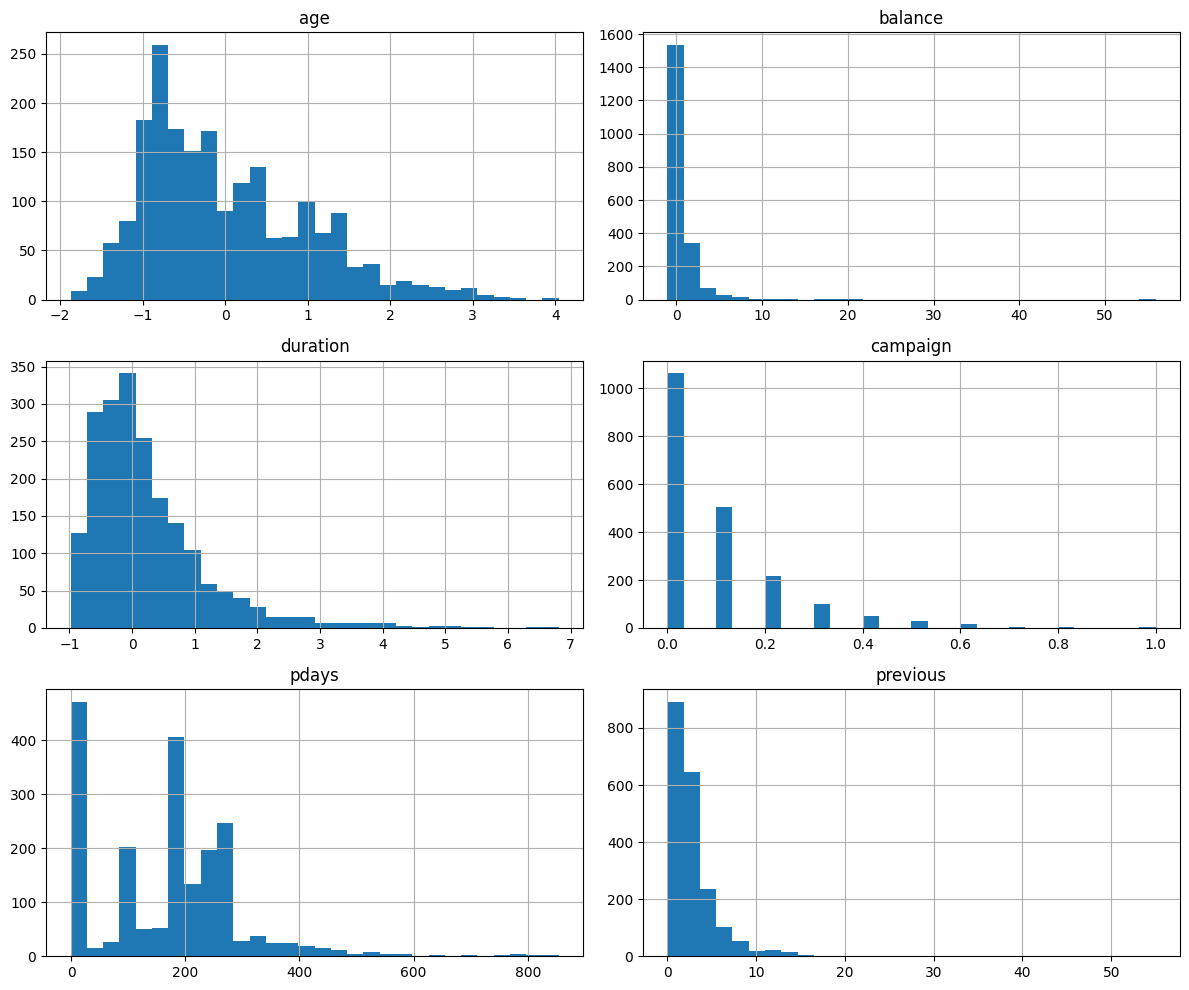

In [28]:
# let's verify distributions

relevant_columns = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']

bank_dataset[relevant_columns].hist(figsize=(12,10), bins=30)
plt.tight_layout()
plt.show()

Most of the histograms are skewed to the left, which could be expected for many of these columns due to the nature of the signal they are capturing. However, many ML algorithms work best when the features are not skewed to either side. 

I'll treat these columns with scaling, logarithmic transformations or both.

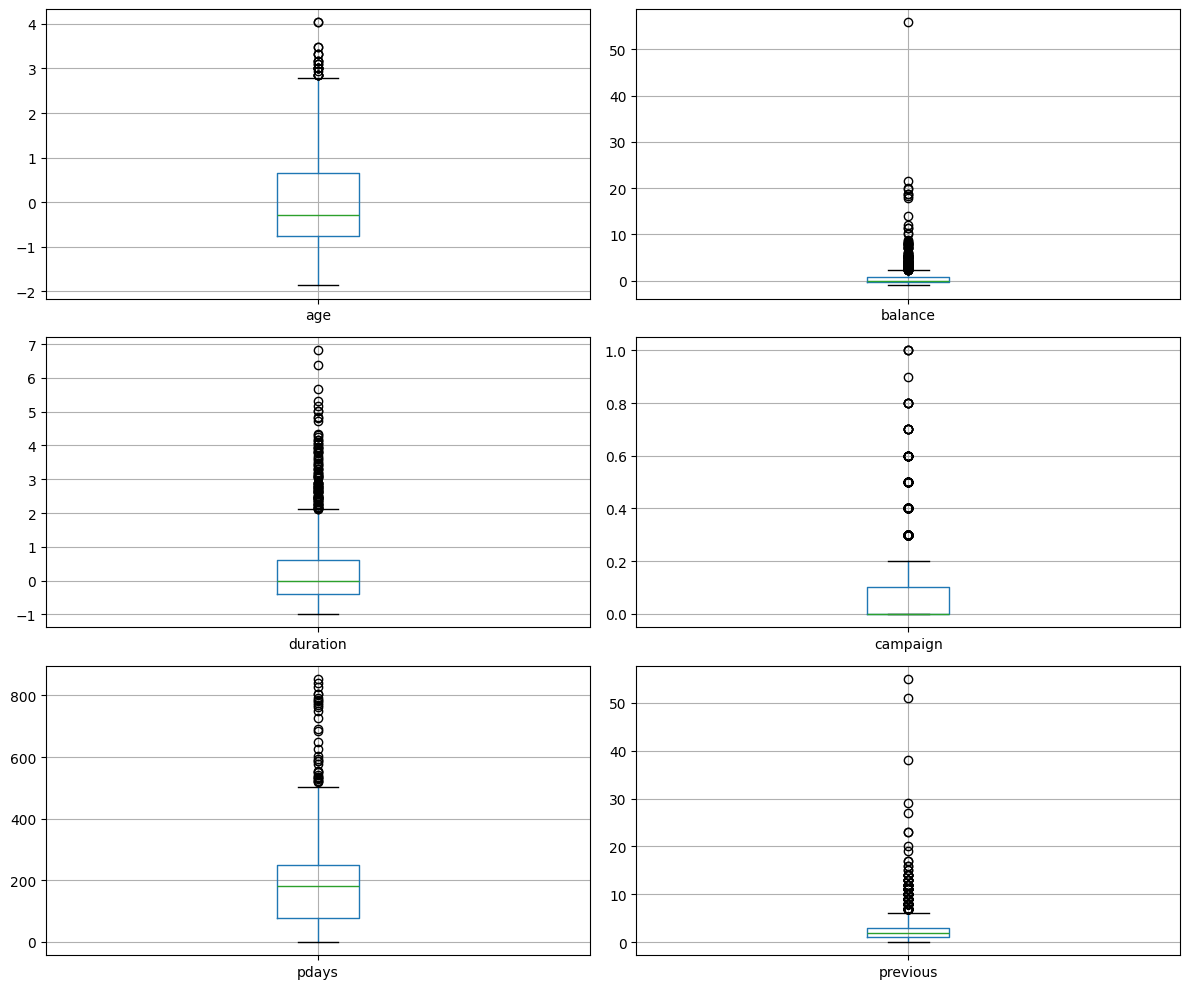

age        -1.872833
balance    -1.060984
duration   -0.982833
campaign    0.000000
pdays      -1.000000
previous    0.000000
dtype: float64

In [29]:
numeric_cols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']

plt.figure(figsize=(12, 10))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 2, i)
    bank_dataset.boxplot(column=col)

plt.tight_layout()
plt.show()

#checking for negative values

bank_dataset[numeric_cols].min()

#decide: drop them or shift them to a positive range before applying log()

Columns 'age' and 'duration' have negative values after rescaling. 'balance' and 'pdays' already had negative values. All columns can be transformed to diminish the negative impact of outliers to ML models. 

<Figure size 1200x1000 with 0 Axes>

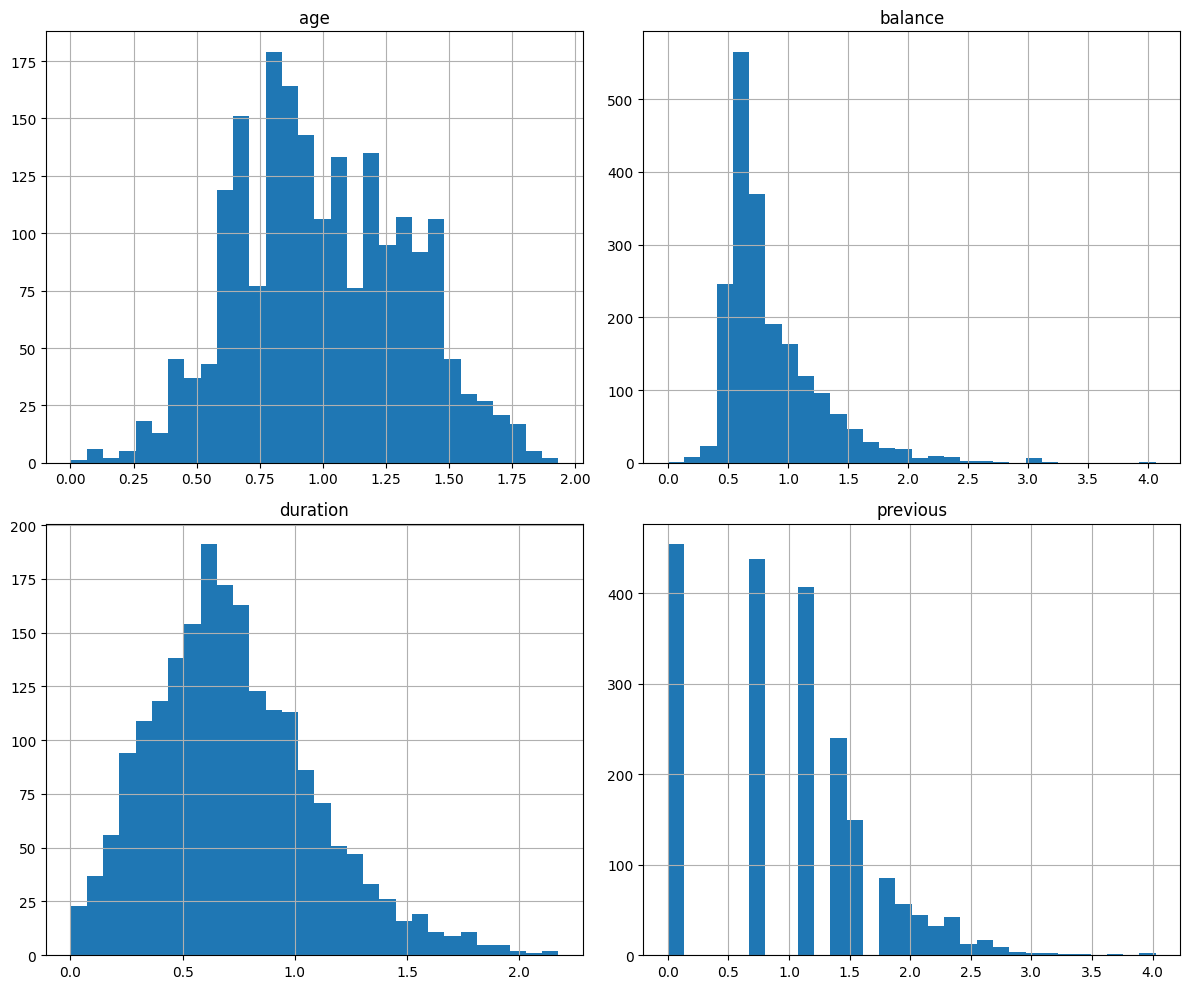

In [30]:
# Use a log transformation to decrease the impact of outliers

numeric_cols = ['age', 'balance', 'duration', 'previous']

plt.figure(figsize=(12, 10))

for i, col in enumerate(numeric_cols, 1):
    bank_dataset[col] = np.log(bank_dataset[col] + abs(min(bank_dataset[col])) + 1)

bank_dataset[numeric_cols].hist(figsize=(12,10), bins=30)
plt.tight_layout()
plt.show()


Here we are have chosen to shift the values to the interval $[1, +\infty]$ before applying a log transformation.

To deal with outliers in 'balance' and 'duration' columns, I used </code>RobustScaler</code>. And then a log transformation over columns 'balance', 'duration', 'campaign' and 'previous' to provide a Gaussian-like distribution.

### 5. created at least one new feature from the existing ones

Due to the dual meaning of the column 'pdays', I knew I had to do something to treat this column. After plenty of reflection and peer interactions, I followed Ciaran's lead on it.

In [31]:
# The 'pdays' column is special because it has a categorical meaning but only numerical values.

# When it is -1, the individual has never been contacted before
bank_dataset['pdays_contacted'] = (bank_dataset['pdays'] != -1).astype(int)

# after separating the different signals in this column it's important to finally scale 'pdays'
bank_dataset['pdays'] = bank_dataset['pdays'].astype(float)
contacted_mask = bank_dataset['pdays'] != -1
bank_dataset.loc[contacted_mask, 'pdays'] = bank_dataset.loc[contacted_mask, 'pdays'] / bank_dataset.loc[contacted_mask, 'pdays'].max()
bank_dataset.loc[~contacted_mask, 'pdays'] = 0

# this modification leaves 'pdays' representing only how long ago the interaction happened (if it happened)

In [32]:
bank_dataset['pdays_contacted'] = (bank_dataset['pdays'] != -1).astype(int)

# taking advantage from numerical encoding
bank_dataset['loan_counter'] = bank_dataset['housing'] + bank_dataset['loan']

# let's check the summary statistics again to see how the transformations affected the data
bank_dataset.head()

,age,default,balance,housing,loan,duration,campaign,pdays,previous,subscribed,...,job_self-employed,job_services,job_student,job_technician,job_unemployed,poutcome_first_contact,poutcome_other,poutcome_success,pdays_contacted,loan_counter
0,0.743767,0,0.668238,1,0,1.624770,0.1,0.153396,1.098612,0,...,False,False,False,True,False,False,False,False,1,1
1,0.976734,0,0.768220,1,1,0.678012,0.1,0.155738,0.693147,0,...,False,False,False,True,False,False,False,False,1,2
2,1.442838,0,0.873966,1,1,0.412593,0.1,0.279859,0.693147,0,...,False,False,False,False,False,False,False,False,1,2
3,1.189834,0,0.670367,1,1,0.763570,0.0,0.278689,1.098612,0,...,False,False,False,False,False,False,False,False,1,2
4,1.345071,0,0.864961,1,0,1.107159,0.0,0.359485,0.693147,0,...,False,False,False,False,False,False,False,False,1,1


From task 1, I concluded that there's an anti-correlation between mortgages and personal loans and the ability to subscribe, especially noticeable when the person has both of these loans. After applying the numerical encoding, combining the information from both of these columns was simple (new column 'loan_counter', inspired from Dermot's notebook) and if this value is ever two, that likely means the person won't be subscribing. 

I created a new feature to better capture the information from the 'pdays' column. The pday column is special because it has a categorical meaning but only numerical values. When it is -1, the individual has never been contacted before, any other number means how many days since the last contact. So the column 'pdays_contacted' comes to answer in a straight-forward manner if the individual has ever been contacted before, leaving the 'pdays' value to only represent how long ago the interaction happened. 

Also, it's finally here when I can properly scale 'pdays' without fearing any lost.

One last check

In [33]:
# let's check the summary statistics again to see how the transformations affected the data

numeric_summary = bank_dataset.describe().T

numeric_summary[['min', '25%', '50%', '75%', 'max']]

,min,25%,50%,75%,max
age,0.000000,0.743767,9.465956e-01,1.259334,1.933470
default,0.000000,0.000000,0.000000e+00,0.000000,1.000000
balance,0.000000,0.598166,7.231835e-01,1.036304,4.059642
housing,0.000000,0.000000,0.000000e+00,1.000000,1.000000
loan,0.000000,0.000000,0.000000e+00,0.000000,1.000000
duration,0.000000,0.467855,6.845264e-01,0.954190,2.174069
campaign,0.000000,0.000000,0.000000e+00,0.100000,1.000000
pdays,0.000000,0.088700,2.131148e-01,0.293911,1.000000
previous,0.000000,0.693147,1.098612e+00,1.386294,4.025352
subscribed,0.000000,0.000000,5.000000e-01,1.000000,1.000000


### Exceptionally clear demonstration of the usefulness of the new feature



most important features:
month_sin           0.162164
month_cos           0.119373
loan_counter        0.109184
duration            0.096965
poutcome_success    0.082049
dtype: float64


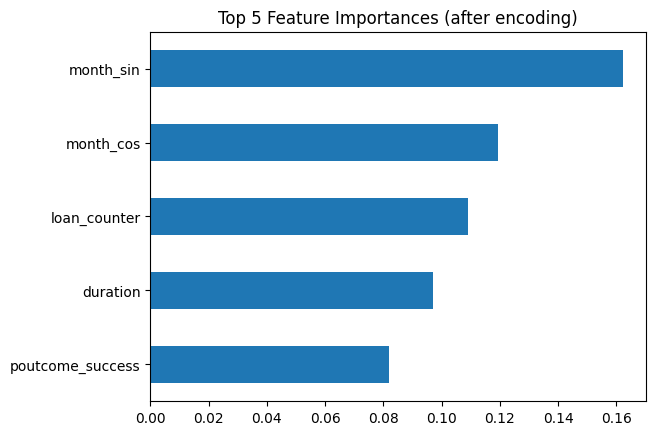

In [34]:
# As Dermot, using Random Forest to prove usefulness of new feature

X = bank_dataset.drop('subscribed', axis=1)
y = bank_dataset['subscribed']

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)


importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print("most important features:")
print(importance.head(5))

importance.head(5).plot(kind='barh')
plt.title('Top 5 Feature Importances (after encoding)')
plt.gca().invert_yaxis()
plt.show()

If well the feature 'pdays_contacted' didn't come up in the top of most useful features, I want to remind the reader that the new feature came from the neccessary to deal with a problematic 'pdays' column. Instead, the new feature 'loan_counter' comes from a deeper analysis recorded in task 1.

#### Miscellaneous

I used this to manually scan produced dataset during the data preparation process. Prof/moderator won't be able to see it. I labelled it as optional

In [35]:
#Optional: save the prepared dataset as a CSV file.
bank_dataset.to_csv('bank_dataset_prepared.csv')